# CS231 - COMPUTER VISION

## Giới thiệu đồ án:
Dự án tập trung vào bài toán Fine-Grained Visual Categorization (FGVC) - phân loại chi tiết 150 loài chim trên tập dữ liệu Birds-525. Áp dụng và so sánh nhiều phương pháp từ truyền thống đến các kiến trúc SOTA (State-of-the-Art) như Bilinear CNN (B-CNN), Vision Transformer (ViT) và CLIP để tìm ra giải pháp tối ưu cho việc nhận diện các đặc trưng nhỏ giữa các loài chim có độ tương đồng cao.

# MEMBER 2:
- Công việc chung (Evaluation & Metrics): Viết script tính toán các độ đo: Accuracy, Precision,Recall,Macro F1.Vẽ Ma trận nhầm lẫn (Confusion Matrix) để phân tích lỗi sâu các loài chim hay bị nhầm với nhau.
- Trích xuất đặc trưng Học sâu: Cài đặt Vision Transformer (ViT-B/16) để trích xuất vector embedding 768 chiều.
- Mô hình phân loại: Random Forest (hoặc SVM) để phân loại dựa trên vector của ViT và Color Histogram.

# Rút trích đặc trưng

## Sử dụng Vision Transformer(ViT) để rút trích đặc trưng:

### Import Thư viện

In [1]:
import os
import numpy as np
import torch
from torchvision import datasets
from torch.utils.data import DataLoader, Dataset
from transformers import AutoImageProcessor, ViTModel
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from tqdm.notebook import tqdm
import warnings

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

warnings.filterwarnings("ignore")

### Thiết lập cấu hình và Kiểm tra GPU

In [2]:
DATA_DIR = '/kaggle/input/datasets/tonnguynb/original-dataset' 
TRAIN_DIR = os.path.join(DATA_DIR, 'train')
VALID_DIR = os.path.join(DATA_DIR, 'val')
TEST_DIR = os.path.join(DATA_DIR, 'test')

# Kiểm tra GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Đang sử dụng thiết bị: {device}")

Đang sử dụng thiết bị: cuda


### Khởi tạo mô hình Vision Transformer (ViT)

In [3]:
MODEL_NAME = "google/vit-base-patch16-224-in21k"
print(f"Đang tải pre-trained model: {MODEL_NAME}...")

processor = AutoImageProcessor.from_pretrained(MODEL_NAME)
model = ViTModel.from_pretrained(MODEL_NAME)

# Đưa model lên GPU và set chế độ evaluation
model = model.to(device)
model.eval() 
print("Tải model thành công!")

Đang tải pre-trained model: google/vit-base-patch16-224-in21k...


preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/502 [00:00<?, ?B/s]

Fast image processor class <class 'transformers.models.vit.image_processing_vit_fast.ViTImageProcessorFast'> is available for this model. Using slow image processor class. To use the fast image processor class set `use_fast=True`.


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

Tải model thành công!


### Khai báo Dataset và DataLoaders

In [4]:
class BirdDataset(Dataset):
    def __init__(self, root_dir, processor):
        self.dataset = datasets.ImageFolder(root_dir)
        self.processor = processor

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        image, label = self.dataset[idx]
        if image.mode != "RGB":
            image = image.convert("RGB")
            
        # Tự động resize và normalize theo chuẩn ViT
        pixel_values = self.processor(images=image, return_tensors="pt").pixel_values.squeeze()
        return pixel_values, label

BATCH_SIZE = 64

print("Đang cấu hình DataLoaders...")
train_dataset = BirdDataset(TRAIN_DIR, processor)
valid_dataset = BirdDataset(VALID_DIR, processor)
test_dataset = BirdDataset(TEST_DIR, processor)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
print(f"Số lượng class: {len(train_dataset.dataset.classes)}")

Đang cấu hình DataLoaders...
Số lượng class: 150


### Định nghĩa hàm trích xuất đặc trưng

In [5]:
def extract_features(dataloader, desc="Extracting"):
    features = []
    labels = []
    
    with torch.no_grad():
        for batch_images, batch_labels in tqdm(dataloader, desc=desc):
            batch_images = batch_images.to(device)
            
            outputs = model(pixel_values=batch_images)
            
            # Lấy đặc trưng từ token [CLS] (đại diện cho ảnh)
            cls_features = outputs.last_hidden_state[:, 0, :]
            
            features.append(cls_features.cpu().numpy())
            labels.extend(batch_labels.numpy())
            
    return np.vstack(features), np.array(labels)

### Thực thi trích xuất

In [6]:
print("BẮT ĐẦU TRÍCH XUẤT ĐẶC TRƯNG...")

X_train, y_train = extract_features(train_loader, desc="Train set")
X_valid, y_valid = extract_features(valid_loader, desc="Valid set")
X_test, y_test = extract_features(test_loader, desc="Test set")

print(f"\nKích thước tập Train: {X_train.shape}")
print(f"Kích thước tập Valid: {X_valid.shape}")
print(f"Kích thước tập Test : {X_test.shape}")

BẮT ĐẦU TRÍCH XUẤT ĐẶC TRƯNG...


Train set:   0%|          | 0/314 [00:00<?, ?it/s]

Valid set:   0%|          | 0/67 [00:00<?, ?it/s]

Test set:   0%|          | 0/70 [00:00<?, ?it/s]


Kích thước tập Train: (20080, 768)
Kích thước tập Valid: (4248, 768)
Kích thước tập Test : (4468, 768)


### Huấn luyện Random Forest

In [7]:
print("Đang huấn luyện Random Forest...")

# Lấy tham số tốt nhất từ kết quả GridSearch
best_params = {'bootstrap': True, 'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 200}

# Khởi tạo mô hình Random Forest chính thức
rf_classifier = RandomForestClassifier(
    **best_params,             
    n_jobs=-1,
    random_state=42
)

# Huấn luyện mô hình trên toàn bộ tập dữ liệu (train + val)
rf_classifier.fit(X_train, y_train)

print("Huấn luyện hoàn tất!")

Đang huấn luyện Random Forest...
Huấn luyện hoàn tất!


### Đánh giá mô hình (Evaluation)

In [8]:
print("--- KẾT QUẢ ĐÁNH GIÁ ---")

# Validation
y_valid_pred = rf_classifier.predict(X_valid)

acc_val = accuracy_score(y_valid, y_valid_pred)
precision_val = precision_score(y_valid, y_valid_pred, average="macro")
recall_val = recall_score(y_valid, y_valid_pred, average="macro")
f1_val = f1_score(y_valid, y_valid_pred, average="macro")

print("===== VAL =====")
print(f"Accuracy : {acc_val:.4f}")
print(f"Precision: {precision_val:.4f}")
print(f"Recall   : {recall_val:.4f}")
print(f"F1-score : {f1_val:.4f}")

# Testing
y_test_pred = rf_classifier.predict(X_test)

acc_test = accuracy_score(y_test, y_test_pred)
precision_test = precision_score(y_test, y_test_pred, average="macro")
recall_test = recall_score(y_test, y_test_pred, average="macro")
f1_test = f1_score(y_test, y_test_pred, average="macro")

print("===== TEST =====")
print(f"Accuracy : {acc_test:.4f}")
print(f"Precision: {precision_test:.4f}")
print(f"Recall   : {recall_test:.4f}")
print(f"F1-score : {f1_test:.4f}")


# Mở comment đoạn dưới nếu bạn muốn xem chi tiết (Precision, Recall, F1) cho từng loài chim cụ thể
classes = train_dataset.dataset.classes
print("\nClassification Report trên tập Test:")
print(classification_report(y_test, y_test_pred, target_names=classes))

--- KẾT QUẢ ĐÁNH GIÁ ---
===== VAL =====
Accuracy : 0.9553
Precision: 0.9578
Recall   : 0.9552
F1-score : 0.9553
===== TEST =====
Accuracy : 0.9570
Precision: 0.9590
Recall   : 0.9570
F1-score : 0.9569

Classification Report trên tập Test:
                               precision    recall  f1-score   support

                ABBOTTS BOOBY       0.93      0.97      0.95        29
   ABYSSINIAN GROUND HORNBILL       1.00      0.93      0.96        29
        AFRICAN PIED HORNBILL       0.97      1.00      0.98        30
          AFRICAN PYGMY GOOSE       0.92      0.83      0.87        29
                ALPINE CHOUGH       1.00      0.96      0.98        27
              AMERICAN AVOCET       1.00      1.00      1.00        29
             AMERICAN BITTERN       1.00      1.00      1.00        27
              AMERICAN DIPPER       1.00      1.00      1.00        30
               AMERICAN PIPIT       1.00      1.00      1.00        29
              AMERICAN WIGEON       1.00      1.0

### Hàm hỗ trợ phân tích lỗi

In [9]:
import matplotlib.pyplot as plt
from PIL import Image
import random
import os
import numpy as np

def get_representative_image(class_name, train_dir=TRAIN_DIR):
    """Lấy ngẫu nhiên một ảnh mẫu của class bị dự đoán nhầm từ tập Train"""
    class_folder = os.path.join(train_dir, class_name)
    if os.path.exists(class_folder):
        images = os.listdir(class_folder)
        if images:
            img_path = os.path.join(class_folder, random.choice(images))
            return Image.open(img_path)
    return None

def analyze_model_results(y_true, y_pred, img_paths, class_names, model_name="Mô hình"):
    """Hàm phân tích và trực quan hóa kết quả đúng/sai"""
    print(f"\n{'='*60}\nPHÂN TÍCH LỖI: {model_name}\n{'='*60}")
    
    correct_idx = np.where(y_true == y_pred)[0]
    incorrect_idx = np.where(y_true != y_pred)[0]
    
    # --- 1. HIỂN THỊ ẢNH ĐOÁN ĐÚNG ---
    print(f"Tổng số ảnh đoán đúng: {len(correct_idx)}")
    num_show_correct = min(5, len(correct_idx))
    
    if num_show_correct > 0:
        fig, axes = plt.subplots(1, num_show_correct, figsize=(20, 4))
        fig.suptitle(f'[{model_name}] VÍ DỤ DỰ ĐOÁN ĐÚNG', fontsize=14, fontweight='bold')
        
        sample_correct = random.sample(list(correct_idx), num_show_correct)
        for i, idx in enumerate(sample_correct):
            img = Image.open(img_paths[idx])
            true_label = class_names[y_true[idx]]
            ax = axes[i] if num_show_correct > 1 else axes
            ax.imshow(img)
            ax.set_title(f"Label: {true_label}", color='green', fontsize=10)
            ax.axis('off')
        plt.show()

    # --- 2. HIỂN THỊ ẢNH ĐOÁN SAI & ẢNH MẪU ĐỂ ĐỐI CHIẾU ---
    print(f"\nTổng số ảnh đoán sai: {len(incorrect_idx)}")
    num_show_incorrect = min(5, len(incorrect_idx))
    
    if num_show_incorrect > 0:
        print("-> Cột Trái: Ảnh bị dự đoán sai | Cột Phải: Ảnh đặc trưng của loài chim bị nhầm lẫn.")
        fig, axes = plt.subplots(num_show_incorrect, 2, figsize=(10, 4 * num_show_incorrect))
        fig.suptitle(f'[{model_name}] PHÂN TÍCH CA SAI LỆCH', fontsize=14, fontweight='bold', y=1.02)
        
        if num_show_incorrect == 1:
            axes = [axes]
            
        sample_incorrect = random.sample(list(incorrect_idx), num_show_incorrect)
        
        for i, idx in enumerate(sample_incorrect):
            img_wrong = Image.open(img_paths[idx])
            true_class = class_names[y_true[idx]]
            pred_class = class_names[y_pred[idx]]
            
            img_representative = get_representative_image(pred_class)
            
            # Vẽ cột trái (Ảnh sai)
            axes[i][0].imshow(img_wrong)
            axes[i][0].set_title(f"THỰC TẾ: {true_class}\n(Model đoán nhầm là: {pred_class})", color='red', fontsize=11)
            axes[i][0].axis('off')
            
            # Vẽ cột phải (Ảnh mẫu)
            if img_representative:
                axes[i][1].imshow(img_representative)
                axes[i][1].set_title(f"ẢNH MẪU CỦA LOÀI:\n{pred_class}", color='blue', fontsize=11)
            else:
                axes[i][1].text(0.5, 0.5, 'Không tìm thấy ảnh mẫu', ha='center')
            axes[i][1].axis('off')
            
        plt.tight_layout()
        plt.show()

### Các ví dụ dự đoán đúng và sai của rút trích đặc trưng theo ViT để train cho Random Forest


PHÂN TÍCH LỖI: VISION TRANSFORMER (ViT)
Tổng số ảnh đoán đúng: 4276


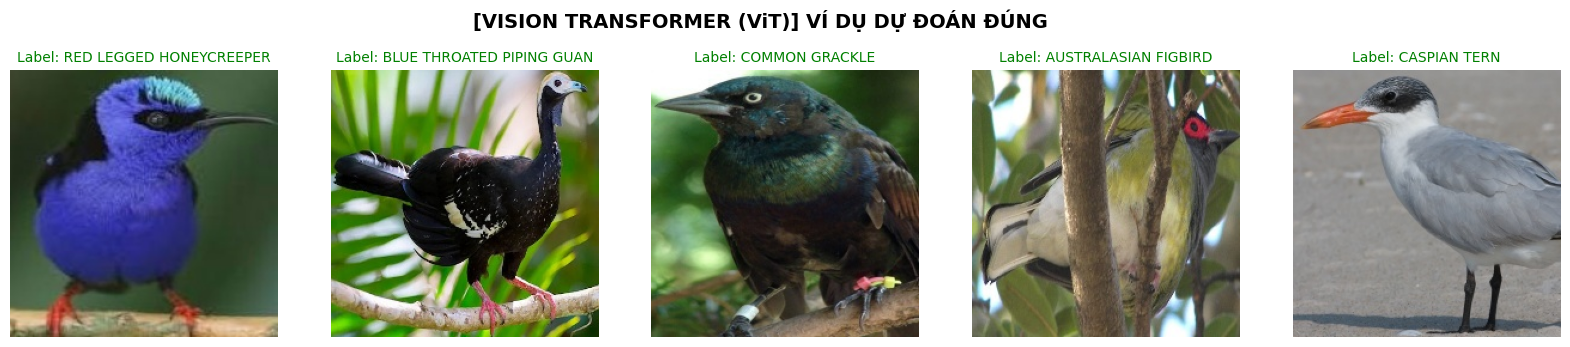


Tổng số ảnh đoán sai: 192
-> Cột Trái: Ảnh bị dự đoán sai | Cột Phải: Ảnh đặc trưng của loài chim bị nhầm lẫn.


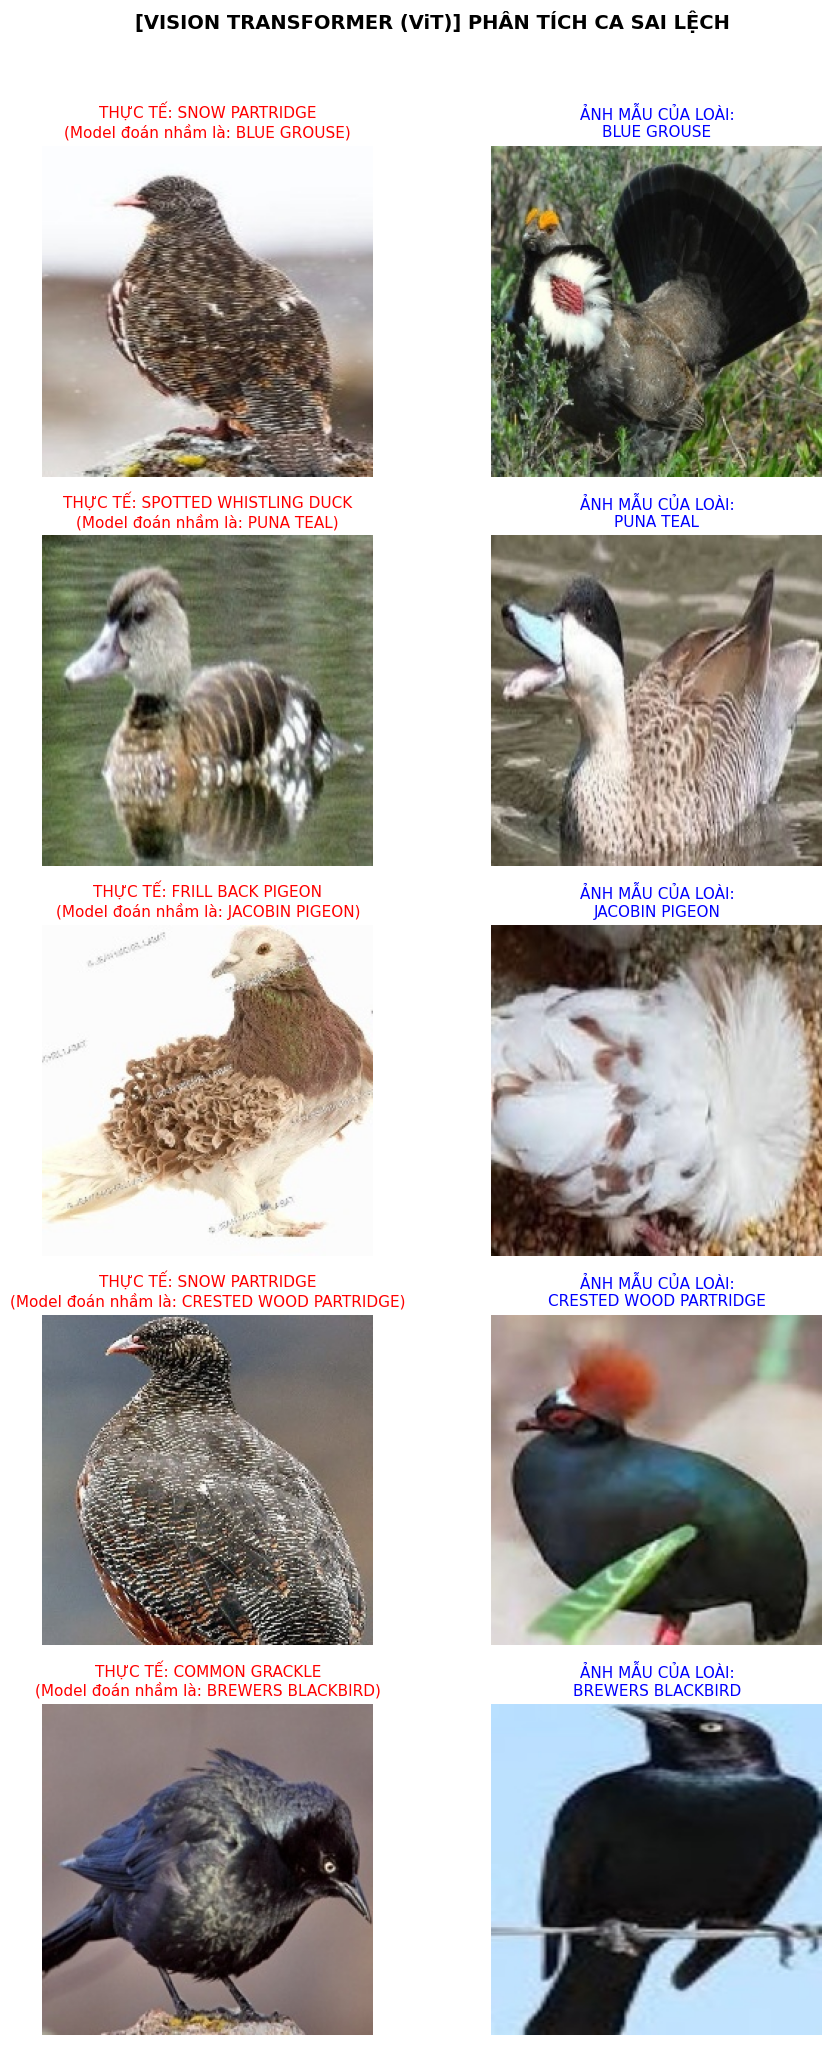

In [10]:
# Lấy danh sách đường dẫn ảnh và tên class (đã có sẵn từ train_dataset/test_dataset)
test_paths_vit = [path for path, label in test_dataset.dataset.imgs]
classes = train_dataset.dataset.classes

# y_test_pred đã được tính ở ngay cell trên (Cell 47)
analyze_model_results(y_test, y_test_pred, test_paths_vit, classes, "VISION TRANSFORMER (ViT)")

### Tạo file .pkl

In [11]:
import joblib

joblib.dump(
    rf_classifier,
    "org_random_forest.pkl"
)

print("RF model saved.")

RF model saved.
